<a href="https://colab.research.google.com/github/Sparda07/CNN-Classification-/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import random
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    f1_score,
    precision_score,
    accuracy_score,
    roc_curve,
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
EXTRACT_DIR = "/content/ba_dataset" if IN_COLAB else "/mnt/data/ba_dataset"

if IN_COLAB:
    print("Upload your dataset ZIP file now...")
    uploaded = files.upload()
    ZIP_PATH = list(uploaded.keys())[0]
    print("Uploaded file:", ZIP_PATH)
else:
    ZIP_PATH = "/mnt/data/Sonographic-Gallbladder-Images-for-BA-Diagnosis-v1.0.4.zip"
    print("Local mode. ZIP_PATH:", ZIP_PATH)

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"ZIP file not found: {ZIP_PATH}")

if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete:", EXTRACT_DIR)
else:
    print("Dataset already extracted:", EXTRACT_DIR)

print("Extracted top-level folders:", os.listdir(EXTRACT_DIR))

root_candidates = list(Path(EXTRACT_DIR).glob("*/data")) + list(Path(EXTRACT_DIR).glob("data"))
if len(root_candidates) == 0:
    raise FileNotFoundError("Could not find the dataset 'data' folder after extraction.")

DATA_ROOT = root_candidates[0]
print("DATA_ROOT:", DATA_ROOT)
print("DATA_ROOT folders:", os.listdir(DATA_ROOT))

Upload your dataset ZIP file now...


Saving Sonographic-Gallbladder-Images-for-BA-Diagnosis-v1.0.4.zip to Sonographic-Gallbladder-Images-for-BA-Diagnosis-v1.0.4 (1).zip
Uploaded file: Sonographic-Gallbladder-Images-for-BA-Diagnosis-v1.0.4 (1).zip
Dataset already extracted: /content/ba_dataset
Extracted top-level folders: ['youngyzzZ-Sonographic-Gallbladder-Images-for-BA-Diagnosis-d8d9178']
DATA_ROOT: /content/ba_dataset/youngyzzZ-Sonographic-Gallbladder-Images-for-BA-Diagnosis-d8d9178/data
DATA_ROOT folders: ['test_data', 'data introduction.txt', 'training_data']


In [ ]:
BA_CLASS = 0
NON_BA_CLASS = 1
POSITIVE_CLASS = BA_CLASS


def read_label_csv(csv_path):
    df = pd.read_csv(csv_path, header=None)
    if df.shape[1] < 2:
        raise ValueError(f"CSV has fewer than 2 columns: {csv_path}")
    df = df.iloc[:, :2]
    df.columns = ["filename", "label"]
    df["filename"] = df["filename"].astype(str)
    df["label"] = df["label"].astype(int)
    return df


def collect_labeled_images(data_root):
    rows = []
    skipped = []
    for folder in ["training_data", "test_data"]:
        image_dir = Path(data_root) / folder
        csv_path = image_dir / "label.csv"
        if not image_dir.exists():
            skipped.append((folder, "folder missing"))
            continue
        if not csv_path.exists():
            skipped.append((folder, "label.csv missing"))
            continue
        temp = read_label_csv(csv_path)
        temp["image_path"] = temp["filename"].apply(lambda x: str(image_dir / x))
        temp["split_source"] = folder
        rows.append(temp)

    if skipped:
        print("Warning: skipped folders:")
        for item in skipped:
            print(" -", item[0], ":", item[1])

    if len(rows) == 0:
        raise FileNotFoundError("No label.csv was found.")

    df = pd.concat(rows, ignore_index=True)
    before = len(df)
    df = df[df["image_path"].apply(os.path.exists)].copy()
    after = len(df)
    if after < before:
        print(f"Warning: removed {before - after} rows because image files were missing.")

    df["patient_id"] = df["filename"].apply(lambda x: str(x).split("_")[0])
    return df


df = collect_labeled_images(DATA_ROOT)
print("Total labeled images:", len(df))
print("Class count (0=BA, 1=non-BA):")
print(df["label"].value_counts().sort_index())

Total labeled images: 4546
Class count (0=BA, 1=non-BA):
label
0    1161
1    3385
Name: count, dtype: int64


In [ ]:
labels = df["label"].values
groups = df["patient_id"].values

split1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(split1.split(df, labels, groups))
train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

split2 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(
    split2.split(
        train_val_df,
        train_val_df["label"].values,
        train_val_df["patient_id"].values,
    )
)
train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df), Counter(train_df["label"]))
print("Val:",   len(val_df),   Counter(val_df["label"]))
print("Test:",  len(test_df),  Counter(test_df["label"]))

Train: 2871 Counter({1: 2124, 0: 747})
Val: 730 Counter({1: 534, 0: 196})
Test: 945 Counter({1: 727, 0: 218})


In [ ]:
# ============================================================
# After your train_df, val_df, test_df split
# ============================================================

import torchvision.models as models
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ─────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────
class Config:
    NUM_CLASSES  = 2
    IMAGE_SIZE   = 224
    BATCH_SIZE   = 16
    EPOCHS       = 20
    LR           = 3e-4
    MIN_LR       = 1e-6
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 2
    PATIENCE     = 4
    SAVE_DIR     = "/content" if IN_COLAB else "/mnt/data"


label_map = {
    0: "BA",
    1: "Non-BA"
}


In [ ]:
# ─────────────────────────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────────────────────────
class BADataset(Dataset):
    """
    cls_label : 0 = BA | 1 = Non-BA
    reg_label : normalized mean grayscale intensity from image
    """

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

        print(f"Caching {len(self.df)} images...")
        self.images = []

        for _, row in self.df.iterrows():
            img = Image.open(row["image_path"]).convert("RGB")
            img = img.resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE), Image.BILINEAR)
            self.images.append(img)

        print("Caching done ✓")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = self.images[idx]

        gray = image.convert("L")
        reg_label = np.array(gray).mean() / 255.0

        if self.transform:
            image = self.transform(image)

        cls_label = torch.tensor(self.df.iloc[idx]["label"], dtype=torch.long)
        reg_label = torch.tensor(reg_label, dtype=torch.float32)

        return image, cls_label, reg_label

In [ ]:
# ─────────────────────────────────────────────────────────────
# Transforms
# ─────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
# ─────────────────────────────────────────────────────────────
# Datasets + DataLoaders
# ─────────────────────────────────────────────────────────────
train_dataset = BADataset(train_df, train_transform)
val_dataset   = BADataset(val_df, val_transform)
test_dataset  = BADataset(test_df, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

Caching 2871 images...
Caching done ✓
Caching 730 images...
Caching done ✓
Caching 945 images...
Caching done ✓
Train : 2871
Val   : 730
Test  : 945


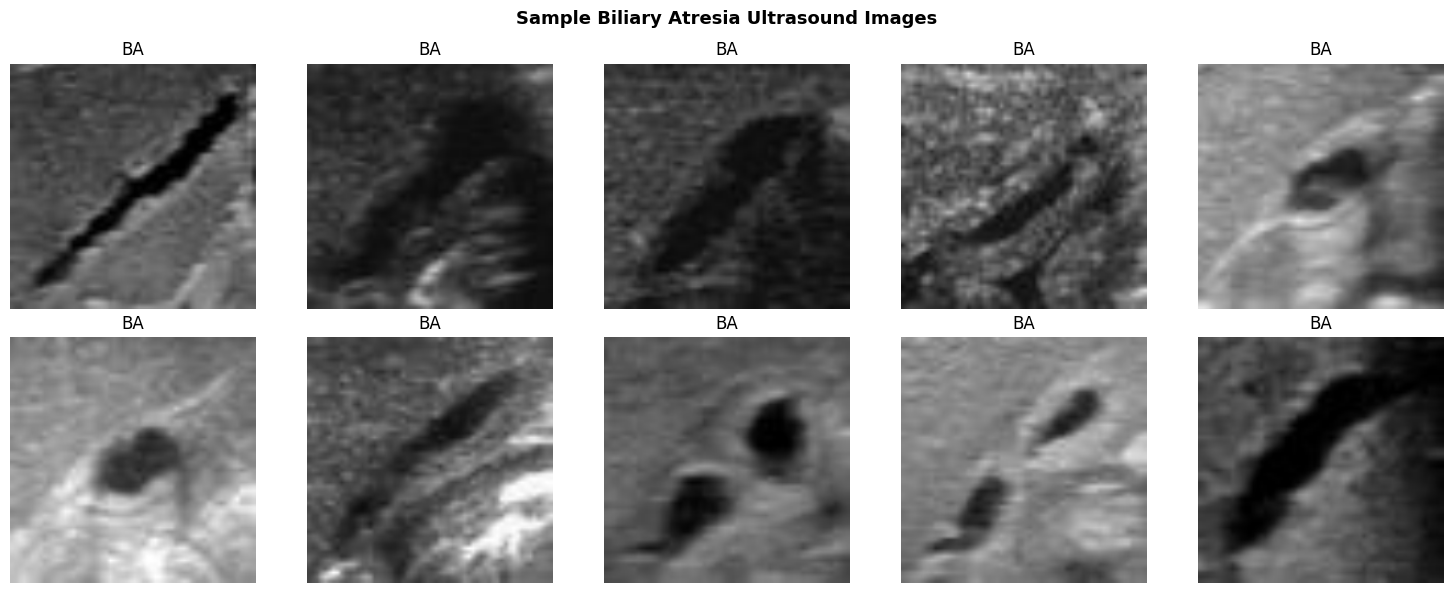

In [ ]:
# ─────────────────────────────────────────────────────────────
# Show Sample Images
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img = train_dataset.images[i]
    label = train_dataset.df.iloc[i]["label"]

    ax.imshow(img)
    ax.set_title(label_map[label])
    ax.axis("off")

plt.suptitle("Sample Biliary Atresia Ultrasound Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# VGG16 Dual Head
# ─────────────────────────────────────────────────────────────
class VGG16DualHead(nn.Module):
    def __init__(self, num_classes=2):
        super(VGG16DualHead, self).__init__()

        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

        for param in vgg.features.parameters():
            param.requires_grad = False

        self.features = vgg.features
        self.avgpool = vgg.avgpool

        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.cls_head = nn.Linear(256, num_classes)
        self.reg_head = nn.Linear(256, 1)

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.shared_fc(x)

        cls = self.cls_head(x)
        reg = self.reg_head(x).squeeze(1)

        return cls, reg

In [ ]:
# ─────────────────────────────────────────────────────────────
# ResNet18 Dual Head
# ─────────────────────────────────────────────────────────────
class ResNet18DualHead(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNet18DualHead, self).__init__()

        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        for name, param in resnet.named_parameters():
            if "layer1" in name or "layer2" in name:
                param.requires_grad = False

        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4,
            resnet.avgpool
        )

        self.shared_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.cls_head = nn.Linear(256, num_classes)
        self.reg_head = nn.Linear(256, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.shared_fc(x)

        cls = self.cls_head(x)
        reg = self.reg_head(x).squeeze(1)

        return cls, reg


vgg_model = VGG16DualHead(Config.NUM_CLASSES).to(device)
resnet_model = ResNet18DualHead(Config.NUM_CLASSES).to(device)

print("VGG16 trainable params:",
      sum(p.numel() for p in vgg_model.parameters() if p.requires_grad))

print("ResNet18 trainable params:",
      sum(p.numel() for p in resnet_model.parameters() if p.requires_grad))


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 70.6MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


VGG16 trainable params: 12977667
ResNet18 trainable params: 10635075


In [ ]:
# ─────────────────────────────────────────────────────────────
# Training Functions
# ─────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, cls_criterion, reg_criterion):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, cls_labels, reg_labels in tqdm(loader, leave=False):
        images = images.to(device)
        cls_labels = cls_labels.to(device)
        reg_labels = reg_labels.to(device)

        cls_out, reg_out = model(images)

        loss_cls = cls_criterion(cls_out, cls_labels)
        loss_reg = reg_criterion(reg_out, reg_labels)
        loss = loss_cls + loss_reg

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(cls_out, dim=1)
        correct += (preds == cls_labels).sum().item()
        total += cls_labels.size(0)

    return total_loss / len(loader), correct / total


def validate_epoch(model, loader, cls_criterion, reg_criterion):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, cls_labels, reg_labels in loader:
            images = images.to(device)
            cls_labels = cls_labels.to(device)
            reg_labels = reg_labels.to(device)

            cls_out, reg_out = model(images)

            loss_cls = cls_criterion(cls_out, cls_labels)
            loss_reg = reg_criterion(reg_out, reg_labels)
            loss = loss_cls + loss_reg

            total_loss += loss.item()

            preds = torch.argmax(cls_out, dim=1)
            correct += (preds == cls_labels).sum().item()
            total += cls_labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()

    all_cls_true = []
    all_cls_pred = []
    all_reg_true = []
    all_reg_pred = []

    with torch.no_grad():
        for images, cls_labels, reg_labels in loader:
            images = images.to(device)

            cls_out, reg_out = model(images)

            preds = torch.argmax(cls_out, dim=1)

            all_cls_true.extend(cls_labels.numpy())
            all_cls_pred.extend(preds.cpu().numpy())

            all_reg_true.extend(reg_labels.numpy())
            all_reg_pred.extend(reg_out.cpu().numpy())

    acc = accuracy_score(all_cls_true, all_cls_pred)
    f1 = f1_score(all_cls_true, all_cls_pred, average="weighted")
    mse = mean_squared_error(all_reg_true, all_reg_pred)
    mae = mean_absolute_error(all_reg_true, all_reg_pred)

    return acc, f1, mse, mae, all_cls_true, all_cls_pred, all_reg_true, all_reg_pred


def run_training(model, model_name, epochs=Config.EPOCHS):
    cls_criterion = nn.CrossEntropyLoss()
    reg_criterion = nn.MSELoss()

    optimizer = AdamW(
        model.parameters(),
        lr=Config.LR,
        weight_decay=Config.WEIGHT_DECAY
    )

    scheduler = CosineAnnealingLR(
        optimizer,
        T_max=epochs,
        eta_min=Config.MIN_LR
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_acc = 0
    patience_count = 0
    save_path = os.path.join(Config.SAVE_DIR, f"{model_name}_best.pth")

    print("\n" + "=" * 65)
    print(f"Training {model_name}")
    print("=" * 65)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(
            model,
            train_loader,
            optimizer,
            cls_criterion,
            reg_criterion
        )

        val_loss, val_acc = validate_epoch(
            model,
            val_loader,
            cls_criterion,
            reg_criterion
        )

        acc, f1, mse, mae, *_ = evaluate(model, val_loader)

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_count = 0
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model: {save_path}")
        else:
            patience_count += 1

        lr_now = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss {train_loss:.4f} Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} | "
            f"F1 {f1:.4f} MSE {mse:.4f} MAE {mae:.4f} | "
            f"LR {lr_now:.2e}"
        )

        if patience_count >= Config.PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(torch.load(save_path, map_location=device))
    print(f"\nBest validation accuracy for {model_name}: {best_val_acc:.4f}")

    return history

In [ ]:
# ─────────────────────────────────────────────────────────────
# Train Models
# ─────────────────────────────────────────────────────────────
vgg_history = run_training(vgg_model, "vgg16_ba")
resnet_history = run_training(resnet_model, "resnet18_ba")


Training vgg16_ba


  0%|          | 0/180 [00:00<?, ?it/s]

Saved best model: /content/vgg16_ba_best.pth
Epoch 01/20 | Train Loss 0.5326 Acc 0.7635 | Val Loss 0.5539 Acc 0.7493 | F1 0.6579 MSE 0.0736 MAE 0.2518 | LR 2.98e-04


  0%|          | 0/180 [00:00<?, ?it/s]

Saved best model: /content/vgg16_ba_best.pth
Epoch 02/20 | Train Loss 0.4069 Acc 0.8265 | Val Loss 0.4049 Acc 0.7973 | F1 0.7590 MSE 0.0254 MAE 0.1300 | LR 2.93e-04


...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eed7126bf60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eed7126bf60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 09/20 | Train Loss 0.1356 Acc 0.9551 | Val Loss 0.3702 Acc 0.8767 | F1 0.8675 MSE 0.0017 MAE 0.0330 | LR 1.74e-04


  0%|          | 0/180 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eed7126bf60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^Exception ignored in: 
^<function _MultiProcessingDataLoaderIter.__del__ at 0x7eed7126bf60>^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^^self._shutdown_workers()
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^^  ^ ^^ ^

Epoch 10/20 | Train Loss 0.1233 Acc 0.9547 | Val Loss 0.3029 Acc 0.8986 | F1 0.8997 MSE 0.0016 MAE 0.0309 | LR 1.50e-04
Early stopping at epoch 10

Best validation accuracy for resnet18_ba: 0.9068


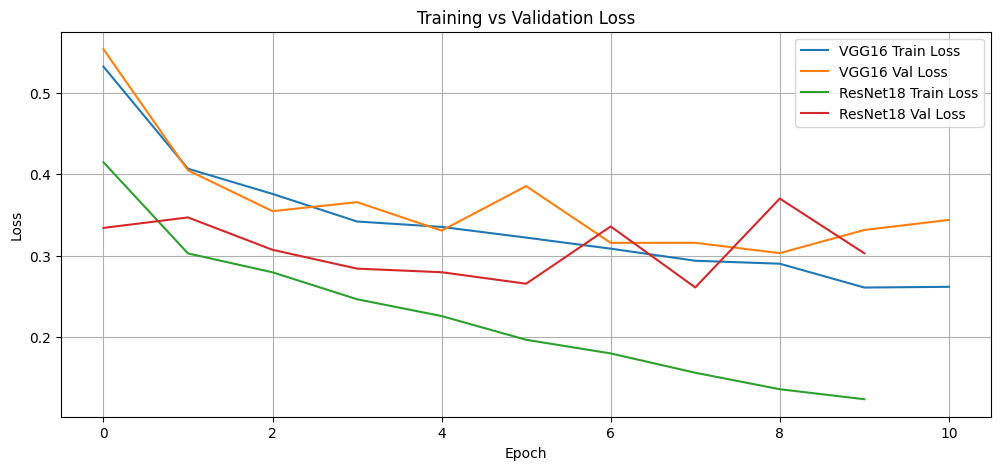

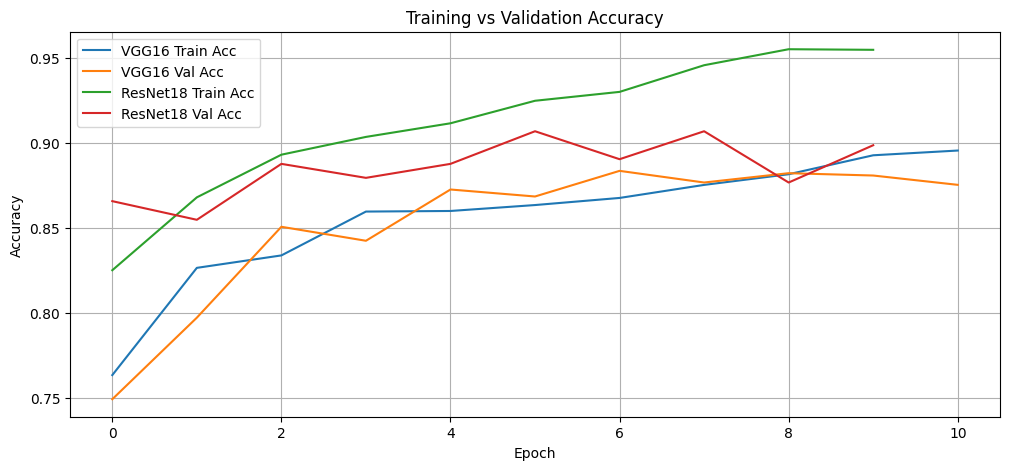

In [ ]:
# ─────────────────────────────────────────────────────────────
# Plot Training History
# ─────────────────────────────────────────────────────────────
def plot_history(vgg_hist, resnet_hist):
    plt.figure(figsize=(12, 5))
    plt.plot(vgg_hist["train_loss"], label="VGG16 Train Loss")
    plt.plot(vgg_hist["val_loss"], label="VGG16 Val Loss")
    plt.plot(resnet_hist["train_loss"], label="ResNet18 Train Loss")
    plt.plot(resnet_hist["val_loss"], label="ResNet18 Val Loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(vgg_hist["train_acc"], label="VGG16 Train Acc")
    plt.plot(vgg_hist["val_acc"], label="VGG16 Val Acc")
    plt.plot(resnet_hist["train_acc"], label="ResNet18 Train Acc")
    plt.plot(resnet_hist["val_acc"], label="ResNet18 Val Acc")
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_history(vgg_history, resnet_history)


───────────────────────────────────────────────────────
VGG16 — Final Test Metrics
───────────────────────────────────────────────────────
Task A Accuracy : 0.8487
Task A F1-score : 0.8510
Task B MSE      : 0.0203
Task B MAE      : 0.1180


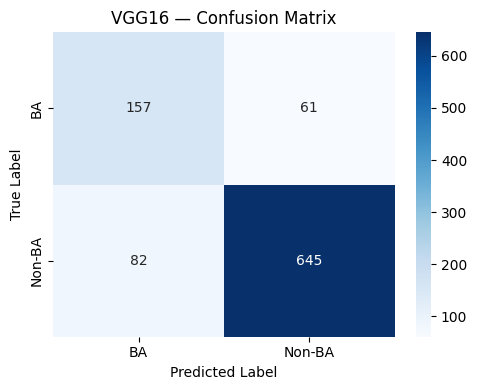

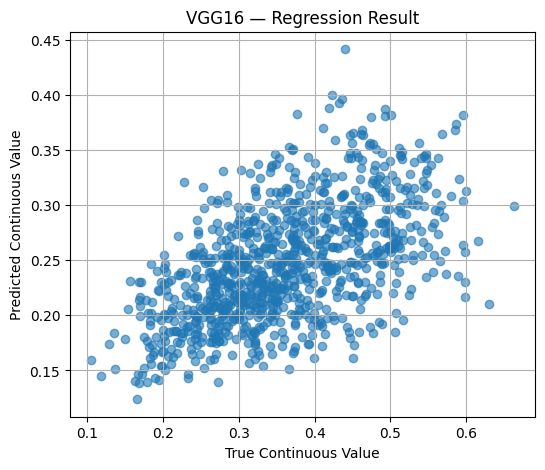


───────────────────────────────────────────────────────
ResNet18 — Final Test Metrics
───────────────────────────────────────────────────────
Task A Accuracy : 0.8836
Task A F1-score : 0.8822
Task B MSE      : 0.0019
Task B MAE      : 0.0348


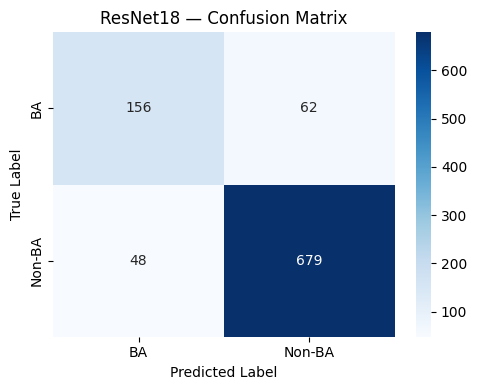

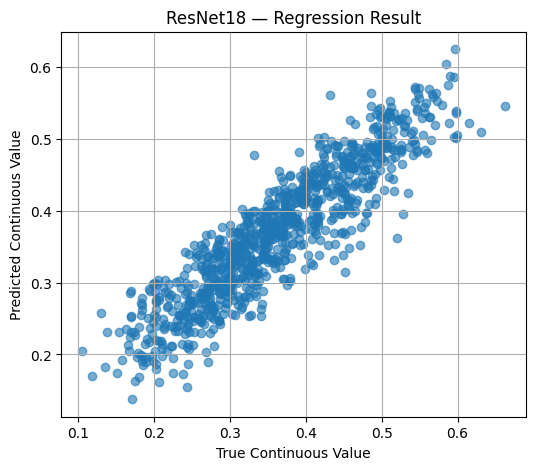

In [ ]:
# ─────────────────────────────────────────────────────────────
# Final Test Evaluation
# ─────────────────────────────────────────────────────────────
def evaluate_and_plot(model, model_name):
    acc, f1, mse, mae, true_cls, pred_cls, true_reg, pred_reg = evaluate(model, test_loader)

    print("\n" + "─" * 55)
    print(f"{model_name} — Final Test Metrics")
    print("─" * 55)
    print(f"Task A Accuracy : {acc:.4f}")
    print(f"Task A F1-score : {f1:.4f}")
    print(f"Task B MSE      : {mse:.4f}")
    print(f"Task B MAE      : {mae:.4f}")

    cm = confusion_matrix(true_cls, pred_cls)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["BA", "Non-BA"],
        yticklabels=["BA", "Non-BA"]
    )
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(true_reg, pred_reg, alpha=0.6)
    plt.title(f"{model_name} — Regression Result")
    plt.xlabel("True Continuous Value")
    plt.ylabel("Predicted Continuous Value")
    plt.grid(True)
    plt.show()

    return {
        "accuracy": acc,
        "f1": f1,
        "mse": mse,
        "mae": mae
    }


vgg_metrics = evaluate_and_plot(vgg_model, "VGG16")
resnet_metrics = evaluate_and_plot(resnet_model, "ResNet18")

      Model  Accuracy  F1-score       MSE       MAE
0     VGG16  0.848677  0.851045  0.020252  0.118002
1  ResNet18  0.883598  0.882222  0.001924  0.034802


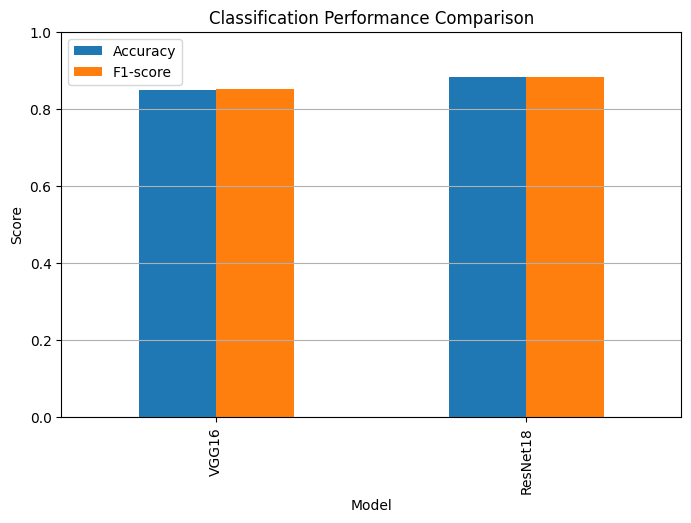

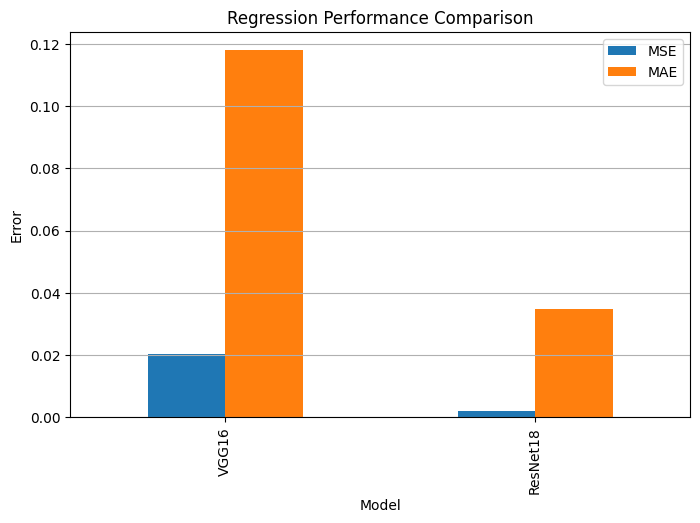

In [ ]:
# ─────────────────────────────────────────────────────────────
# Model Comparison Table
# ─────────────────────────────────────────────────────────────
metrics_df = pd.DataFrame({
    "Model": ["VGG16", "ResNet18"],
    "Accuracy": [vgg_metrics["accuracy"], resnet_metrics["accuracy"]],
    "F1-score": [vgg_metrics["f1"], resnet_metrics["f1"]],
    "MSE": [vgg_metrics["mse"], resnet_metrics["mse"]],
    "MAE": [vgg_metrics["mae"], resnet_metrics["mae"]]
})

print(metrics_df)

metrics_df.plot(x="Model", y=["Accuracy", "F1-score"], kind="bar", figsize=(8, 5))
plt.title("Classification Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

metrics_df.plot(x="Model", y=["MSE", "MAE"], kind="bar", figsize=(8, 5))
plt.title("Regression Performance Comparison")
plt.ylabel("Error")
plt.grid(axis="y")
plt.show()

In [ ]:
# ─────────────────────────────────────────────────────────────
# Fixed Grad-CAM
# ─────────────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.hook = self.target_layer.register_forward_hook(self.forward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output
        output.register_hook(self.save_gradient)

    def save_gradient(self, grad):
        self.gradients = grad

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()

        image_tensor = image_tensor.unsqueeze(0).to(device)
        image_tensor.requires_grad = True

        cls_out, reg_out = self.model(image_tensor)

        if class_idx is None:
            class_idx = torch.argmax(cls_out, dim=1).item()

        self.model.zero_grad()

        score = cls_out[0, class_idx]
        score.backward()

        if self.gradients is None:
            raise RuntimeError("Gradients were not captured. Check target layer.")

        if self.activations is None:
            raise RuntimeError("Activations were not captured. Check target layer.")

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam.detach().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, class_idx

    def remove_hooks(self):
        self.hook.remove()


def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = tensor.cpu() * std + mean
    img = torch.clamp(img, 0, 1)

    return img.permute(1, 2, 0).numpy()


def show_gradcam(model, model_name, dataset, index=0):
    image_tensor, true_label, reg_label = dataset[index]

    if model_name == "VGG16":
        target_layer = model.features[-1]

    elif model_name == "ResNet18":
        target_layer = model.backbone[7][-1].conv2

    else:
        raise ValueError("model_name must be 'VGG16' or 'ResNet18'")

    gradcam = GradCAM(model, target_layer)

    cam, pred_class = gradcam.generate(image_tensor)

    gradcam.remove_hooks()

    original_img = denormalize_image(image_tensor)

    cam_img = Image.fromarray(np.uint8(cam * 255))
    cam_img = cam_img.resize((Config.IMAGE_SIZE, Config.IMAGE_SIZE))
    cam_img = np.array(cam_img) / 255.0

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title(f"Original\nTrue: {label_map[int(true_label)]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam_img, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(original_img)
    plt.imshow(cam_img, cmap="jet", alpha=0.45)
    plt.title(f"{model_name}\nPredicted: {label_map[pred_class]}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

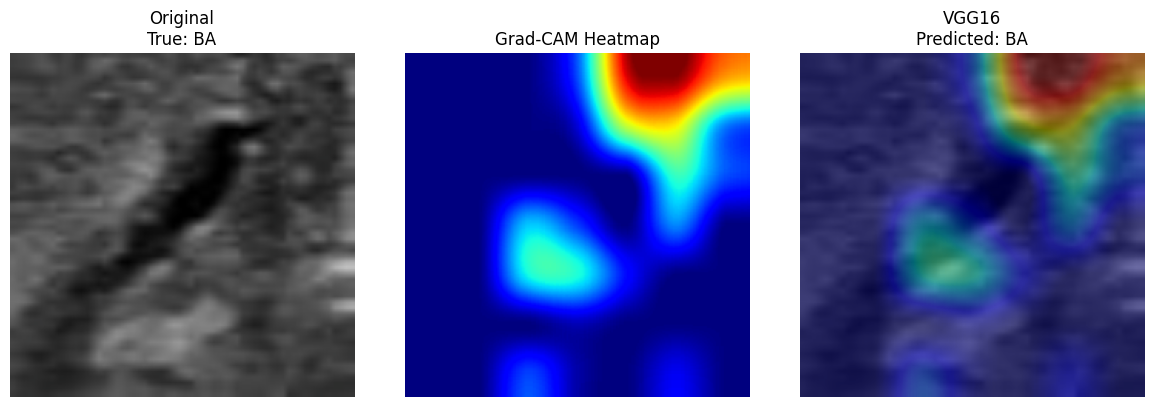

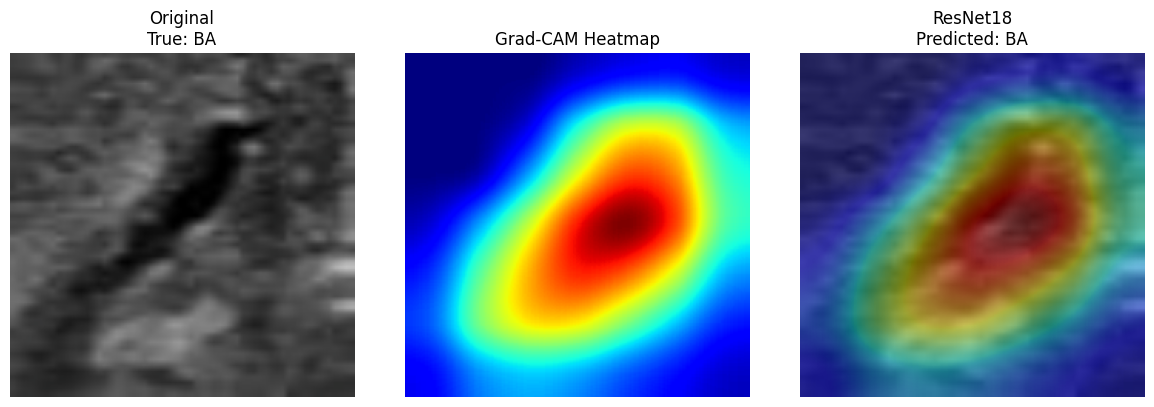

In [ ]:
# ─────────────────────────────────────────────────────────────
# Show Grad-CAM for one test image
# ─────────────────────────────────────────────────────────────
show_gradcam(vgg_model, "VGG16", test_dataset, index=0)
show_gradcam(resnet_model, "ResNet18", test_dataset, index=0)


Grad-CAM for Test Image Index: 0


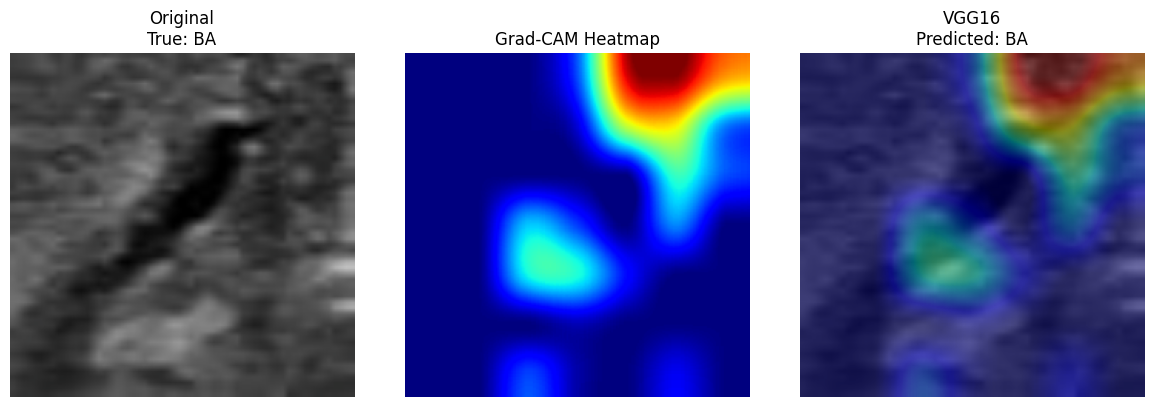

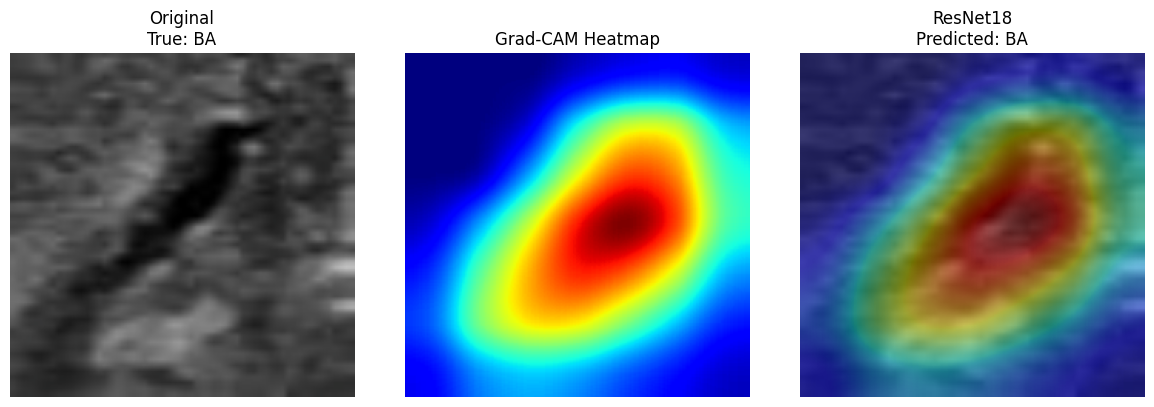


Grad-CAM for Test Image Index: 1


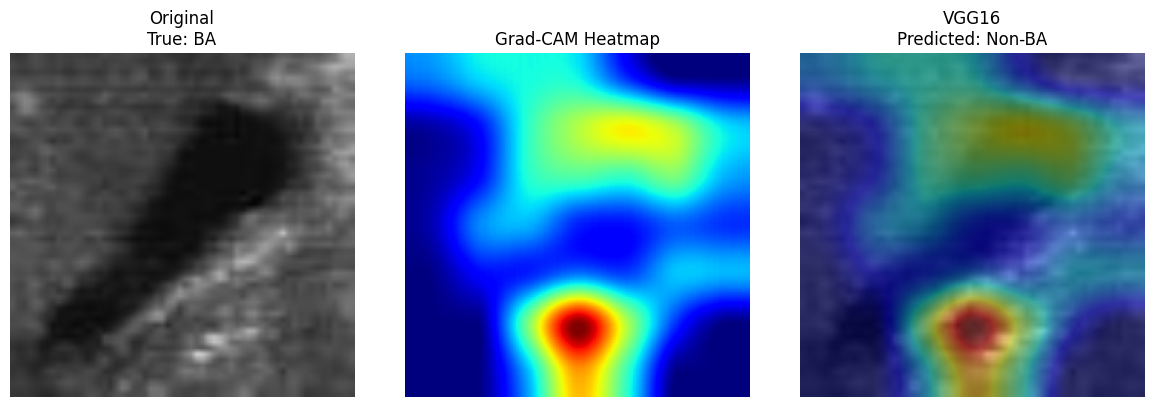

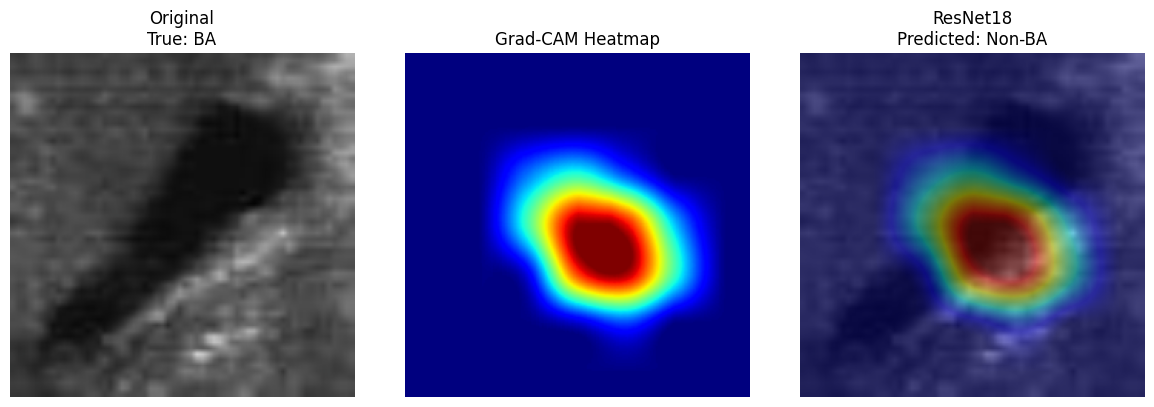


Grad-CAM for Test Image Index: 2


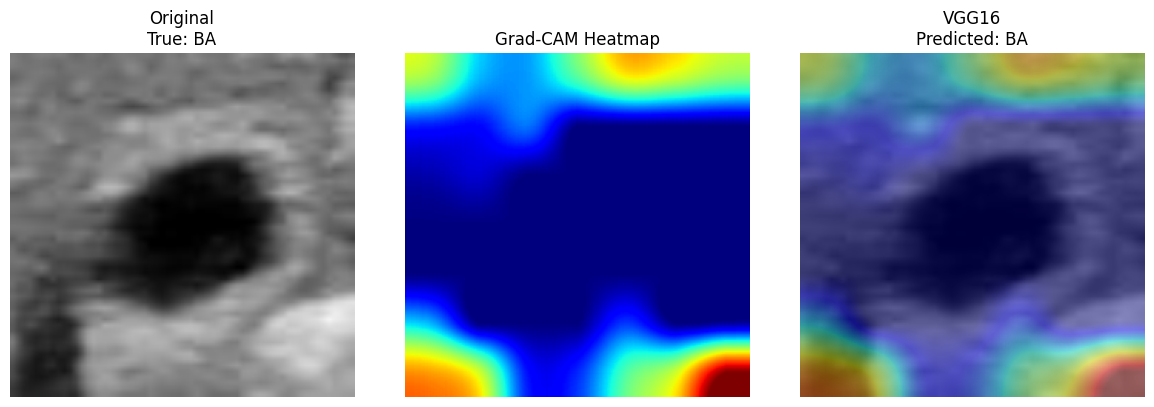

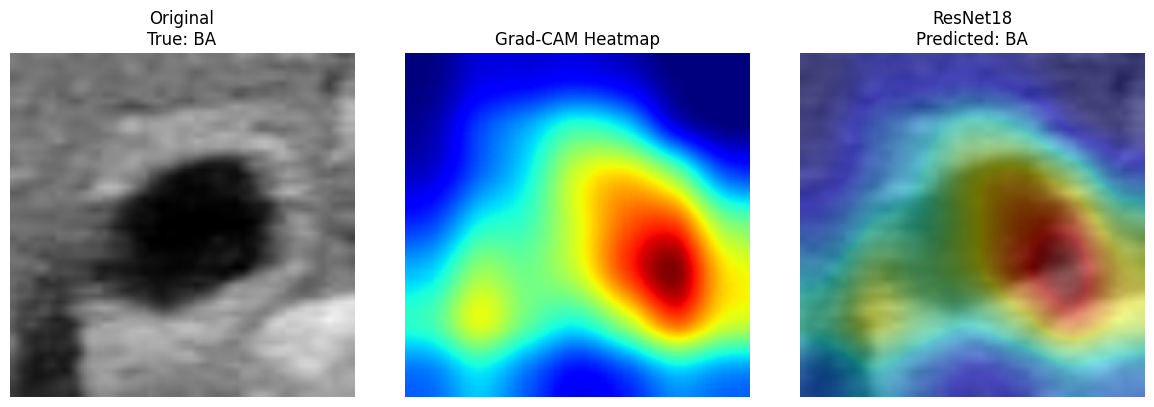

In [ ]:
# ─────────────────────────────────────────────────────────────
# Show Grad-CAM for multiple test images
# ─────────────────────────────────────────────────────────────
for idx in range(3):
    print(f"\nGrad-CAM for Test Image Index: {idx}")
    show_gradcam(vgg_model, "VGG16", test_dataset, index=idx)
    show_gradcam(resnet_model, "ResNet18", test_dataset, index=idx)